In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ox.settings.use_cache = True

In [ ]:
comuna = "Ñuñoa, Santiago, Chile"

G = ox.graph_from_place(
    comuna,
    network_type="drive",
    simplify=True
)

G = ox.convert.to_undirected(G)

nodos, edges = ox.graph_to_gdfs(G)

print(f"Cantidad de nodos: {len(nodos)}")
print(f"Cantidad de aristas: {len(edges)}")

Cantidad de nodos: 2736
Cantidad de aristas: 3977


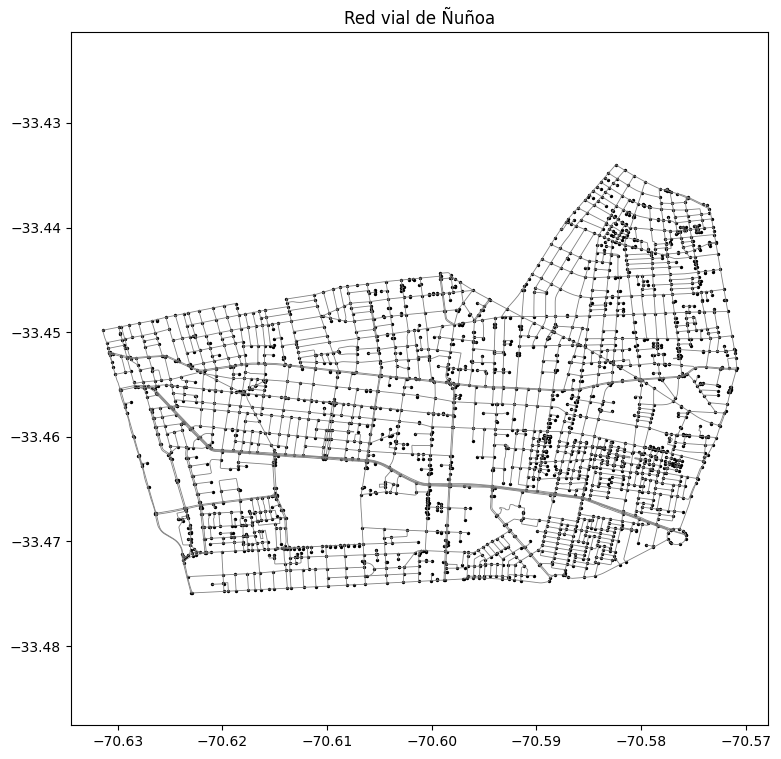

In [3]:
fig, ax = plt.subplots(figsize=(9, 9))

edges.plot(
    ax=ax,
    linewidth=0.6,
    color="gray"
)

nodos.plot(
    ax=ax,
    markersize=2,
    color="black"
)

plt.title("Red vial de Ñuñoa")
plt.axis("equal")
plt.show()

In [4]:
grados = dict(G.degree())

nodos["grado"] = nodos.index.map(grados)

resumen_grados = nodos["grado"].value_counts().sort_index()
display(resumen_grados)

grado
1     447
2      41
3    1582
4     655
5       7
6       4
Name: count, dtype: int64

In [5]:
prop_grado_3_4 = nodos["grado"].isin([3, 4]).mean()
prop_grado_1_2 = nodos["grado"].isin([1, 2]).mean()

print(f"proporcion de nodos con grado 3 o 4: {prop_grado_3_4:.2%}")
print(f"proporcion de nodos con grado 1 o 2: {prop_grado_1_2:.2%}")

proporcion de nodos con grado 3 o 4: 81.76%
proporcion de nodos con grado 1 o 2: 17.84%


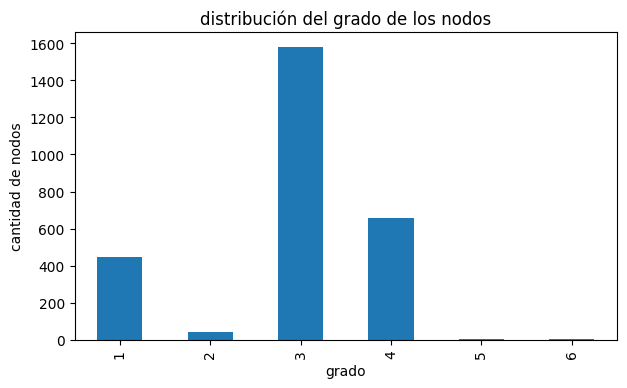

In [6]:
plt.figure(figsize=(7, 4))

resumen_grados.plot(kind="bar")

plt.title("distribución del grado de los nodos")
plt.xlabel("grado")
plt.ylabel("cantidad de nodos")
plt.show()

In [7]:
G_bearing = ox.add_edge_bearings(G.copy()) # añade el angulo de cada arista, opcional, pero se los dejo para que sigan jugando con el dataset
                                            # y revisen docu.
_, edges_bearing = ox.graph_to_gdfs(G_bearing)

edges_bearing = edges_bearing.dropna(subset=["bearing"]).copy()

edges_bearing[["bearing", "length"]].head()

bearing      length
u        v          key                        
13877015 15092685   0    340.561042   19.067135
         479512123  0     76.556413  132.619618
         3634244593 0    254.753201    6.384763
         4444830133 0    166.271975  146.826420
13877020 15092686   0    269.610852   82.120528

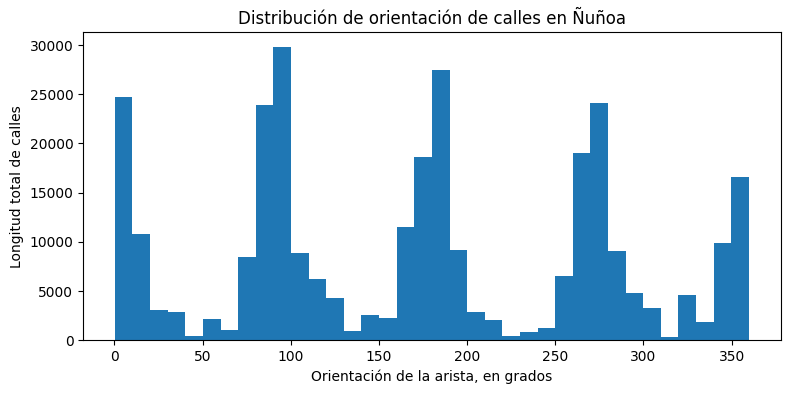

In [8]:
plt.figure(figsize=(9, 4))

plt.hist(
    edges_bearing["bearing"],
    bins=36,
    weights=edges_bearing["length"]
)

plt.title("Distribución de orientación de calles en Ñuñoa")
plt.xlabel("Orientación de la arista, en grados")
plt.ylabel("Longitud total de calles")
plt.show()

In [9]:
edges_bearing["bearing_axial"] = edges_bearing["bearing"] % 180

bins = np.arange(0, 181, 10)

edges_bearing["bin_orientacion"] = pd.cut(
    edges_bearing["bearing_axial"],
    bins=bins,
    include_lowest=True,
    right=False
)

orientacion = (
    edges_bearing
    .groupby("bin_orientacion", observed=False)["length"]
    .sum()
    .reset_index()
)

orientacion["proporcion"] = orientacion["length"] / orientacion["length"].sum()

orientacion.sort_values("proporcion", ascending=False).head()

,bin_orientacion,length,proporcion
9,"[90, 100)",54319.529895,0.177068
0,"[0, 10)",52133.383342,0.169942
8,"[80, 90)",42683.352360,0.139137
17,"[170, 180)",35051.785624,0.114260
16,"[160, 170)",21498.542711,0.070080


In [ ]:
# agrupación más robusta de orientaciones dominantes
# consideramos que 0grados y 180grados representan el mismo eje axial.

prop_0_180 = orientacion.loc[
    orientacion["bin_orientacion"].astype(str).isin(["[0, 10)", "[170, 180)"]),
    "proporcion"
].sum()

prop_90 = orientacion.loc[
    orientacion["bin_orientacion"].astype(str).isin(["[80, 90)", "[90, 100)"]),
    "proporcion"
].sum()

concentracion_ejes_grilla = prop_0_180 + prop_90

print(f"concentración eje 0°/180°: {prop_0_180:.2%}")
print(f"concentración eje 90°: {prop_90:.2%}")
print(f"concentración conjunta en ejes tipo grilla: {concentracion_ejes_grilla:.2%}")

Concentración eje 0°/180°: 28.42%
Concentración eje 90°: 31.62%
Concentración conjunta en ejes tipo grilla: 60.04%


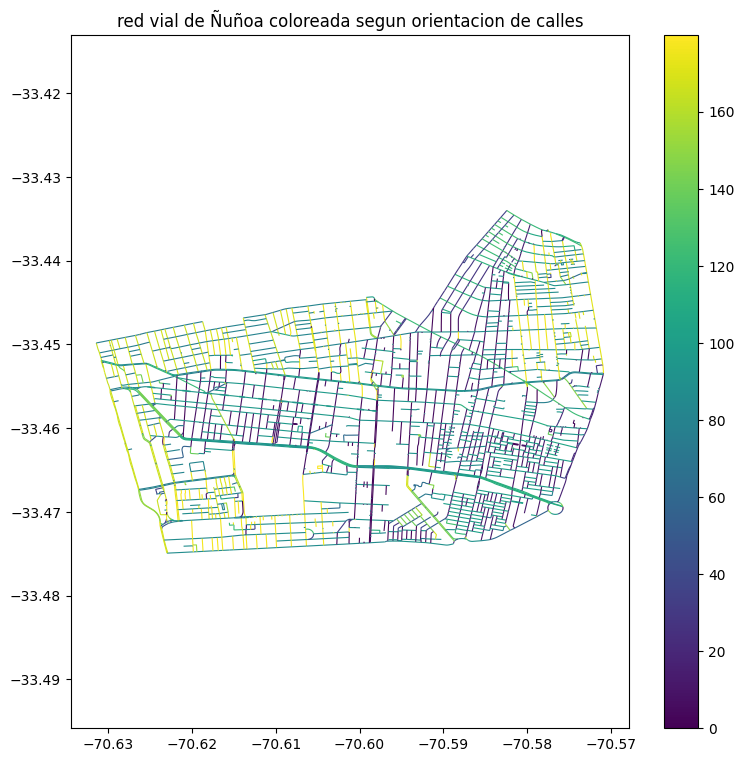

In [11]:
edges_plot = edges_bearing.copy()

fig, ax = plt.subplots(figsize=(9, 9))

edges_plot.plot(
    ax=ax,
    column="bearing_axial",
    linewidth=0.8,
    legend=True
)

plt.title("red vial de Ñuñoa coloreada segun orientacion de calles")
plt.axis("equal")
plt.show()

In [12]:
resumen = pd.DataFrame([
    {
        "metrica": "Nodos",
        "valor": len(nodos)
    },
    {
        "metrica": "Aristas",
        "valor": len(edges)
    },
    {
        "metrica": "Proporción nodos grado 3 o 4",
        "valor": prop_grado_3_4
    },
    {
        "metrica": "Proporción nodos grado 1 o 2",
        "valor": prop_grado_1_2
    }
])

display(resumen)

,metrica,valor
0,Nodos,2736.000000
1,Aristas,3977.000000
2,Proporción nodos grado 3 o 4,0.817617
3,Proporción nodos grado 1 o 2,0.178363


In [14]:
concentracion_ejes_grilla

0.6004064460621652

In [15]:
prop_grado_3_4

0.8176169590643275

In [ ]:
if concentracion_ejes_grilla >= 0.50 and prop_grado_3_4 >= 0.60:
    conclusion = "la red presenta características predominantemente cercanas a una grilla, aunque con irregularidades locales."
elif concentracion_ejes_grilla >= 0.40 and prop_grado_3_4 >= 0.45:
    conclusion = "la red presenta una estructura mixta, con rasgos relevantes de grilla."
else:
    conclusion = "la red presenta una estructura más irregular o radial."

print(conclusion)

la red presenta características predominantemente cercanas a una grilla, aunque con irregularidades locales.


La red vial de Ñuñoa presenta una morfología predominantemente cercana a una grilla, aunque con irregularidades locales propias de una comuna real. 

Esta conclusión se sustenta en dos resultados principales. Primero, el 81,76% de los nodos tiene grado 3 o 4, lo que indica una alta presencia de intersecciones conectadas en varias direcciones. 

Segundo, cerca del 60% de la longitud vial se concentra en dos ejes principales: uno cercano a 0°/180° y otro cercano a 90°. Esta combinación sugiere una red con direcciones dominantes aproximadamente ortogonales.

Ojo que una forma probablemente mucho más sencilla es analizar el grado. Pero la idea de este desarrollo es mostrar formas más completas que les pueden servir. 

Se podría decir que esta morfología de grilla con direcciones dominantes puede facilitar la movilidad urbana al ofrecer múltiples rutas alternativas para desplazarse, lo que puede reducir la congestión en ciertas vías.

Sin embargo, también puede aumentar la vulnerabilidad ante bloqueos, ya que si una intersección clave se bloquea, podría afectar significativamente el flujo de tráfico en varias direcciones debido a la alta conectividad de los nodos.